## 5. The modulation transfer function

In retinal imaging, we are interested in whether we can resolve rods and cones in an image. Thus it is important to quantify how spatial frequencies are transmitted through the eye's optics, including any aberrations. The modulation transfer function is the power spectrum of the PSF and characterises the proportion of contrast present in the object that is preserved in the image formed by an optical system

Lets look at the psf at time zero for the first eye again

In [1]:
import numpy
import matplotlib.pylab as plt
from tqdm import tqdm, trange, tqdm_notebook
from astropy.io import fits
%matplotlib inline
import aotools

from matplotlib import animation, rc
from IPython.display import HTML
import PIL.Image as Image
import scipy.signal
j = 0+1j


In [2]:
fitsdata = fits.open('tabai5mm.fits')
data=fitsdata[0].data

wavelength=833e-3 #(this is the wavelength data was taken at in microns)
wavelength_m=833e-9 #(wavelength in nanometres - we'll use this later)
diameter=5e-3 #(pupil diameter in m)
array_size=128

padding=2

data[:,:,0:2]=0

Create the psfs for the first eye again

In [3]:
firsteye = data [0,:,:]
frames=len(firsteye[:,0])
psfs = numpy.zeros((frames, padding*array_size, padding*array_size))
wfs = numpy.zeros((frames, array_size, array_size))
z=aotools.zernikeArray(66,array_size)
z=z[1:]
zflat = numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))
for n in tqdm(range(frames)):
    
    #convert to radians!
    wf = numpy.dot(firsteye[n],zflat)
    wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
    wf*=aotools.circle(array_size/2, array_size)
    wf*=(2*numpy.pi)/wavelength #convert to radians
    wfs[n]=wf
    padded_pupil=numpy.zeros((array_size*padding, array_size*padding), dtype=numpy.complex64)
    phase = numpy.exp(j*wf)
    padded_pupil[:array_size,:array_size]=phase
    
    psf = numpy.abs(aotools.ft2(padded_pupil, delta=diameter/array_size))**2
    psfs[n] = psf

average_psf = numpy.mean(psfs,axis=0)
average_psf = average_psf/numpy.max(average_psf)    

100%|███████████████████████████████████████████████████████████████████████████████| 808/808 [00:03<00:00, 253.55it/s]


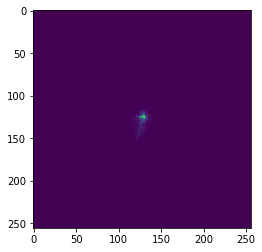

In [4]:
plt.imshow(average_psf)

The MTF is the modulus of the Fourier transform of the PSF

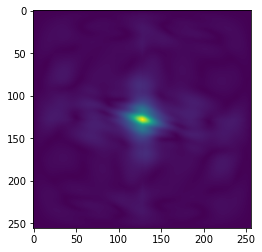

In [5]:
mtf = numpy.abs(aotools.fouriertransform.ft2(average_psf,diameter/array_size))
plt.imshow(mtf)

We can compare this to the MTF for a diffraction limited PSF with the same size pupil

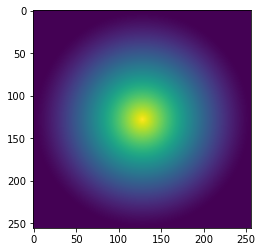

In [6]:
pixel_scale_psf_deg = (wavelength_m/(padding*diameter))*180/numpy.pi
dlcomplex_phase = numpy.exp(j*0)*aotools.circle(array_size/2, array_size)

dlpadded_pupil = numpy.zeros((int(array_size*padding), int(array_size*padding)), dtype=numpy.complex64)
dlpadded_pupil[:array_size, :array_size] = dlcomplex_phase

dlpsf = numpy.abs(aotools.ft2(dlpadded_pupil, delta=diameter/array_size))**2
dlmtf = numpy.abs(aotools.fouriertransform.ft2(dlpsf,delta=pixel_scale_psf_deg))

dlmtf1d = aotools.azimuthal_average(dlmtf)
plt.imshow(dlmtf)

Lets plot the MTF against spatial frequencies for the first eye:

(0.0, 1.0)

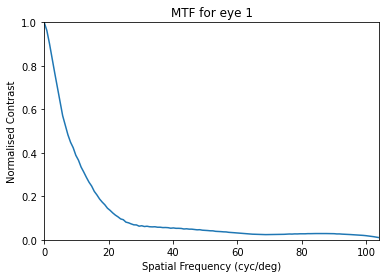

In [7]:
spatial_scales = numpy.fft.fftshift(numpy.fft.fftfreq(mtf.shape[0],pixel_scale_psf_deg))[int(mtf.shape[0]*0.5):]
mtf1d = aotools.azimuthal_average(mtf)
plt.plot(spatial_scales,mtf1d/max(mtf1d))
plt.title('MTF for eye 1')
plt.xlabel('Spatial Frequency (cyc/deg)')
plt.ylabel('Normalised Contrast')
plt.xlim(0,numpy.max(spatial_scales))
plt.ylim(0,1)

The cut-off frequency where the contrast falls to zero is given by $\frac{\text{pupil size}}{\text{wavelength}}$ - don't forget to convert this to cycles per degree.  The cutoff frequency is higher for larger pupil diameters, and thus a higher pupil diameter increases visual resolution.  This is why when taking retinal images we tend to dilate the pupil.

In [8]:
cf=((diameter/wavelength_m))*(numpy.pi/180)
print('cut-off frequency = %f cycles per degree'%cf)

cut-off frequency = 104.761660 cycles per degree


Let's plot both the real eye psf and the diffraction limited PSF and compare the two:

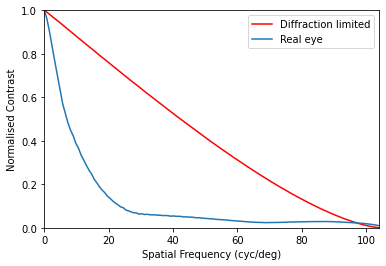

In [9]:
plt.plot(spatial_scales, dlmtf1d/max(dlmtf1d),color='red',label='Diffraction limited')
plt.plot(spatial_scales, mtf1d/max(mtf1d), label = 'Real eye')
plt.xlabel('Spatial Frequency (cyc/deg)')
plt.ylabel('Normalised Contrast')
plt.xlim(0,numpy.max(spatial_scales))
plt.ylim(0,1)
plt.legend()

As we can see, the MTF of the real eye decreases much more sharply than the diffraction limited MTF as spatial frequency increases.

This is a useful scale to help us quantify vision.  Lets try this with the average psfs calculated for a few more eyes:

In [10]:
def av_psf(wfdata,ppt):
    wfs = numpy.zeros((frames, array_size, array_size))
    psfs = numpy.zeros((frames,array_size*padding,array_size*padding))
    for n in (range(frames)):

        wf = numpy.dot(wfdata[ppt,n,:],zflat)
        wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
        wf*=aotools.circle(array_size/2, array_size)
        wf*=(2*numpy.pi)/wavelength #convert to radians
        wfs[n,:,:]=wf
        padded_pupil=numpy.zeros((int(padding*array_size),int(padding*array_size)),dtype=numpy.complex64)
        padded_pupil[:array_size,:array_size]=numpy.exp(j*wf) 
        psf = numpy.abs(aotools.ft2(padded_pupil, delta=diameter/array_size))**2
        psfs[n,:,:]=psf
    average_psf = numpy.mean(psfs,axis=0)
    
    return average_psf

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:51<00:00,  3.44s/it]


(0.0, 1.0)

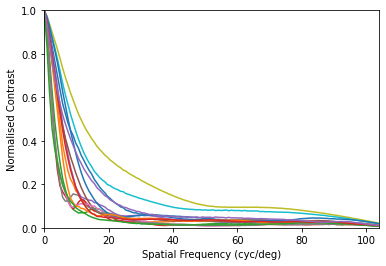

In [11]:
for n in tqdm(range(15)): #lets look at the first 15

    average_psf=av_psf(data,n)
    mtf2 = abs(numpy.fft.fftshift(numpy.fft.fft2(average_psf)))
    mtf1d2 = aotools.azimuthal_average(mtf2)
        
    
    sf = numpy.linspace(-numpy.floor(mtf2.shape[0]/2.), numpy.ceil((mtf2.shape[0]-1)/2.), mtf2.shape[0])
    plt.plot(spatial_scales, mtf1d2/max(mtf1d2))
    
plt.xlabel('Spatial Frequency (cyc/deg)')
plt.ylabel('Normalised Contrast')
plt.xlim(0,numpy.max(spatial_scales))
plt.ylim(0,1)

If we take into account the diffraction limit of the pupil and the cone spacing of the fovea, the highest frequency the human eye can really resolve is about 1 cycle per arcminute - or 60 cycles per degree (Hirsch et.al., Vision Res. Vol. 29, No. 9, pp. 1095-I 101, 1989).  